### 🤖 LLM and AI Agent Development Courses  
**✨ All courses available for just ₹399 INR / $9.99 USD ✨**

| Course | Description | Enroll |
|--------|-------------|---------|
| **🎯 Master OpenAI Agent Builder** | Build and deploy AI agents visually using OpenAI Agent Builder, ChatKit, RAG, Chatbot, AI Assistant with MCP, AWS, RDS MySQL | [Enroll Now](https://kgptalkie.com/agent-builder) |
| **🔥 MCP Mastery** | Build MCP servers & clients with Python, Streamlit, ChromaDB, LangChain, LangGraph agents, and Ollama integrations | [Enroll Now](https://kgptalkie.com/mcp) |
| **📊 Private Agentic RAG with LangChain** | Step-by-Step Guide to RAG with LangChain v1, LangGraph, and Ollama (Qwen3, Gemma3, DeepSeek-R1, LLAMA, FAISS) | [Enroll Now](https://kgptalkie.com/agentic-rag) |
| **🔧 Master LangGraph and LangChain** | Agentic RAG and Chatbot, AI Agent with LangChain v1, Qwen3, Gemma3, DeepSeek-R1, LLAMA 3.2, FAISS Vector Database | [Enroll Now](https://kgptalkie.com/langgraph) |
| **⚡ Master Langchain and Ollama** | Master Langchain v1, Local LLM Projects with Ollama, Qwen3, Gemma3, DeepSeek-R1, LLAMA 3.2, Complete Integration Guide | [Enroll Now](https://kgptalkie.com/langchain) |
| **🔬 Fine Tuning LLM** | Learn transformer architecture fundamentals and fine-tune LLMs with custom datasets | [Enroll Now](https://kgptalkie.com/fine-tuning-llm) |

---

### 🌐 Join the Community & Stay Connected

- 🔗 **Join the Discord Community:** https://discord.gg/RFjwbkNa  
- 📺 **Subscribe on YouTube (63K+ learners):** http://www.youtube.com/@KGPTalkie

---


## Advanced RAG Concept - Data Ingestion Pipeline for PageRAG
### Page-wise Document Processing with LLM Metadata Extraction

Learning Objectives:
- Extract text from PDFs page by page
- Extract metadata using LLM (structured output)
- Store in ChromaDB with rich metadata

#### Real-World Use Cases:
1. Financial Analysis: Process SEC filings (10-K, 10-Q)
2. Legal: Organize contracts and case documents
3. Research: Index academic papers with smart metadata
4. Enterprise: Build searchable document repositories
5. Compliance: Track regulatory documents

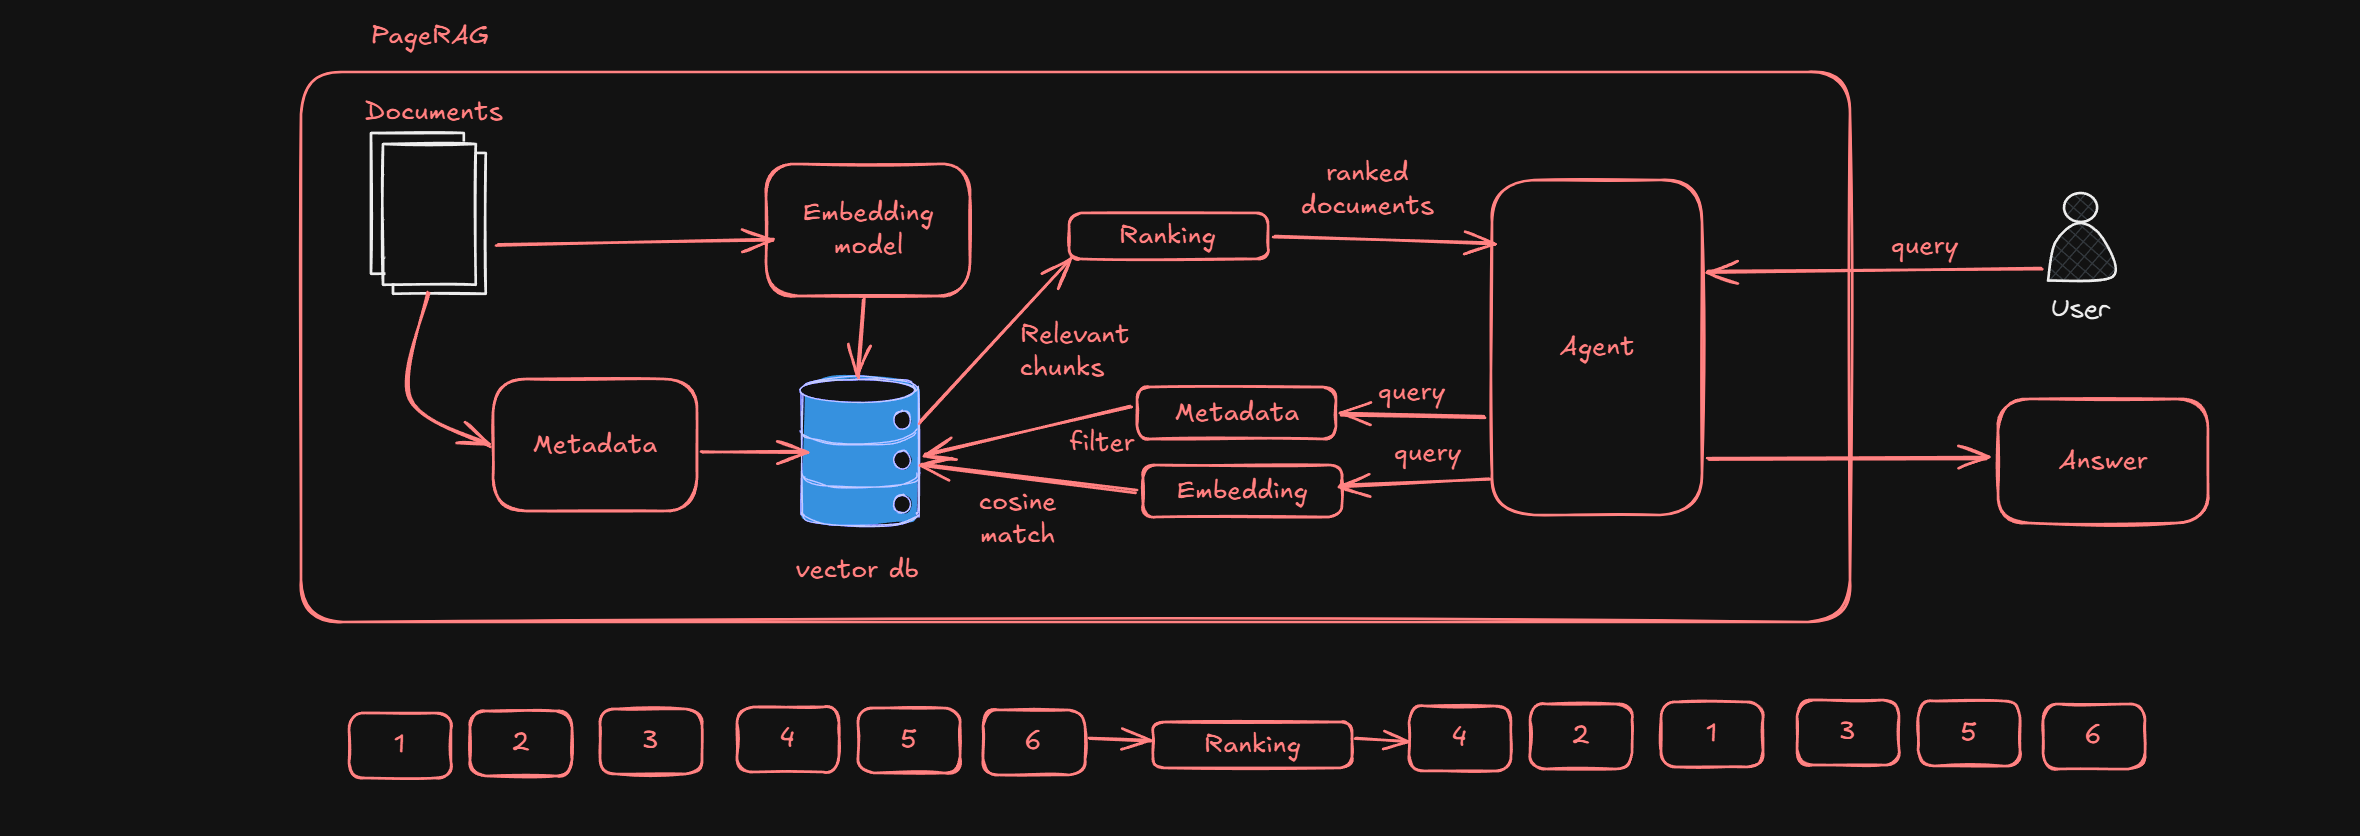

In [1]:
# Advanced RAG - Data Ingestion Pipeline
# Page-wise Document Processing with Filename-based Metadata Extraction
import os
from langfuse.langchain import CallbackHandler
from dotenv import load_dotenv
load_dotenv()

import hashlib
from pathlib import Path

from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings
from langchain_core.documents import Document

from docling.document_converter import DocumentConverter

d:\coding\ai_learning\laxmimerit\Agentic-RAG-with-LangGraph-and-Ollama\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# configurations
DATA_DIR = "data"
CHROMA_DIR = "./chroma_financial_db"
COLLECTION_NAME = "financial_docs"
EMBEDDING_MODEL = 'nomic-embed-text'
BASE_URL = 'http://localhost:11434'

langfuse_trace = CallbackHandler()

In [3]:
# ollama pull nomic-embed_text
embeddings = OllamaEmbeddings(
    model=EMBEDDING_MODEL,
    base_url=BASE_URL,
    num_ctx=8192
)

vector_store = Chroma(
    collection_name=COLLECTION_NAME,
    embedding_function=embeddings,
    persist_directory=CHROMA_DIR,
)

### Metadata Extraction

In [4]:
"""
    Extract metadata from filename.
    
    Expected format: {company} {doc_type} {quarter} {year}.pdf
    Examples:
    - amazon 10-k 2024.pdf

    
    Returns:
        dict with company_name, doc_type, fiscal_year, fiscal_quarter
    """

def extract_metadata_from_filename(filename: str) -> dict:

    name = filename.replace('.pdf', '')
    print(f"name: {name}")
    parts = name.split()
    print(f"parts: {parts}")

    metadata = {}
    if len(parts) == 4: # The files has quarter -> amazon 10-q q1 2024.pdf
        metadata['fiscal_quarter'] = parts[2]
        metadata['fiscal_year'] = int(parts[3])
    else:
        metadata['fiscal_quarter'] = None
        metadata['fiscal_year'] = int(parts[2])

    metadata['company_name'] = parts[0]
    metadata['doc_type'] = parts[1]

    return metadata


In [5]:
extract_metadata_from_filename('amazon 10-k 2023.pdf')
extract_metadata_from_filename('amazon 10-q q1 2024.pdf')

name: amazon 10-k 2023
parts: ['amazon', '10-k', '2023']
name: amazon 10-q q1 2024
parts: ['amazon', '10-q', 'q1', '2024']


{'fiscal_quarter': 'q1',
 'fiscal_year': 2024,
 'company_name': 'amazon',
 'doc_type': '10-q'}

### Extract text from each page of PDF

In [6]:
# def extract_pdf_pages(pdf_path):
#     converter = DocumentConverter()
#     result = converter.convert(pdf_path)
#     page_break = "<!-- page break -->"
#     markdown_text = result.document.export_to_markdown(
#         page_break_placeholder=page_break
#     )
#     pages = markdown_text.split(page_break)
#     return pages

In [6]:
from pypdf import PdfReader


def extract_pdf_pages(pdf_path):
    reader = PdfReader(pdf_path)

    page_break = "<!-- page break -->"

    pages_text = []

    for page in reader.pages:
        text = page.extract_text() or ""
        pages_text.append(text)

    markdown_text = page_break.join(pages_text)

    pages = markdown_text.split(page_break)

    return pages

In [7]:
pages = extract_pdf_pages('data/amazon/amazon 10-q q1 2024.pdf')

In [8]:
# pages
len(pages)

52

In [9]:
print(pages[10])

Table of Contents
The following table summarizes, by major security type, our cash, cash equivalents, restricted cash, and marketable securities that are measured at fair
value on a recurring basis and are categorized using the fair value hierarchy (in millions):
 December 31, 2023 March 31, 2024
  
Total
Estimated
Fair Value
Cost or
Amortized
Cost
Gross
Unrealized
Gains
Gross
Unrealized
Losses
Total
Estimated
Fair Value
Cash $ 11,706 $ 11,633 $ — $ — $ 11,633 
Level 1 securities:
Money market funds 39,160 28,676 — — 28,676 
Equity securities (1) 4,658 2,575 
Level 2 securities:
Foreign government and agency securities 505 19 — — 19 
U.S. government and agency securities 1,699 2,641 1 (89) 2,553 
Corporate debt securities 27,805 38,636 — (146) 38,490 
Asset-backed securities 1,646 1,554 — (45) 1,509 
Other debt securities 104 102 — (3) 99 
$ 87,283 $ 83,261 $ 1 $ (283) $ 85,554 
Less: Restricted cash, cash equivalents, and marketable
securities (2) (503) (480)
Total cash, cash equivale

In [10]:
# """Compute SHA-256 hash of file content."""
import hashlib

def compute_file_hash(file_path: str) -> str:
    sha256_hash = hashlib.sha256()
    with open(file_path, "rb") as f:
        for byte_block in iter(lambda: f.read(4096), b""):
            sha256_hash.update(byte_block)
    return sha256_hash.hexdigest()

In [11]:
compute_file_hash('data/amazon/amazon 10-q q1 2024.pdf')

'c08079bc14250c896f3ca151f9a72ecc1ddcb9ca8e5b021539e91af10fae5c4b'

In [12]:
compute_file_hash('data/amazon/amazon 10-q q1 2024 copy.pdf')

'c08079bc14250c896f3ca151f9a72ecc1ddcb9ca8e5b021539e91af10fae5c4b'

In [13]:
# track the processed files
existing_docs = vector_store.get(where={"file_hash": {"$ne": ""}}, include=['metadatas'])
processed_hashes = [m.get('file_hash') for m in existing_docs['metadatas'] if m.get('file_hash')]
processed_hashes = set(processed_hashes)
existing_docs

{'ids': ['7e0da097-7617-4b94-a93e-00ddaff401f1',
  '5c95d562-d34d-4058-8385-d8a16db3b5ce',
  '277e5bf7-2c59-42bc-98b8-2c3134ea7528',
  '209893c3-066a-4726-8954-c7a911649a68',
  '296313df-e128-4b41-a154-2d9e3019a1ec',
  'a9a578a5-9758-4f9a-b1da-4649d37b8804',
  '63185c82-6634-471f-87cc-3cf0fb8fbf1a',
  '5989c185-2126-49f1-a137-c4024e116d9e',
  '28e71ed0-65af-46a5-882a-acf3422e9421',
  '2fe9211d-9574-41e0-85d4-ec4973ae3d3c',
  'd0ff2bf1-a6c0-4dff-a2ae-21b1c774f332',
  '9fdfcd8b-7b02-4e2c-a23a-e19ace0c5dfe',
  '3cf8da34-a717-41f2-8281-615942733c88',
  'f09b02c2-d165-4e79-93e4-fee99f887c2f',
  'b0d79d9b-3fc0-442e-948c-553725983d7b',
  'fb700a7d-e8c8-4f2f-b3a3-9acddb4a972c',
  '672336f5-f18d-4dc6-bf14-82e632ad2962',
  '119d093e-fad1-47d1-8cda-6307cbbaca7f',
  'f32c36a7-a774-4b29-a6b2-94cfb7b2382d',
  '29e1f60a-1f22-47e3-86bd-2687c5db8216',
  '3bf256e4-4262-415d-a998-5b9302839017',
  '1747c237-e2ab-4f4e-8343-e6b00839b546',
  'a2eb5ee7-21fa-45ec-bd5c-50864b47f2b9',
  'bf4b5f0e-8a14-453b-8994-

In [14]:
processed_hashes

{'068176ab665682096a79859d73b805c7b2fda05331e503f26d893b582353464e',
 '1dceed8775b7b56432618aff917e08f9fe9573921f397a79b14bad5ab31e469a',
 '2c84425b68ab497014a25423984b2b8edc62c5de9a0b32abc605d92814408df7',
 '3f24e07aadeef2a3d0f40febf932f3d75d9e679b51b2bdfb47c66a606e589691',
 '46106605128d8b0dfc668e25b7cc70bdfc68e87fa8ba5d7aad8b0456665d3db9',
 '51ab83179bff647b1b2521836748d83939671d40a1d954fad9df93cd720e5784',
 '552615e47708aa125f69140f69d6bbd4c45f99981e4ed384f2d727d0665da8a8',
 '5b582c59f1d1fa81d5112c9e0b9aa87afdbc9f42418daace257bc360e0f61ef7',
 '60258a17806063663ac83b5fb5422d22bec255cfecbec842c5039e08992e6a46',
 '6e5549c7b20b0fbc5f482397070a1e85cbf8643c801ff570903f52366b11154f',
 '78b0dbb103f6cf647752e56e8ecde7ac392d8e2b661296acfc6c9ca2f7e28c78',
 'a06e0bf6d1ba3aac6b82958c381af08b4d476677484170264f6ae8d64fc4fe67',
 'b19b1f176c5ceaf9e6ea52907013480eb17716962351f8fdfe0ad4b13bb33ed0',
 'bfb57cd34d8c3d9f650b54f4914d712f7d88d57aa7b374886e23101da3228356',
 'c08079bc14250c896f3ca151f9a72ecc

### Documents Ingestion in Vector DB

In [15]:
def ingest_docs_in_vectordb(pdf_path):
    print(f"Processing: {pdf_path.name}")

    file_hash = compute_file_hash(pdf_path)
    if file_hash in processed_hashes:
        print(f"[SKIP] already processed: {pdf_path}")
        return 

    pages = extract_pdf_pages(pdf_path)
    file_metadata = extract_metadata_from_filename(pdf_path.name)

    processed_pages = []
    for page_num, page_text in enumerate(pages, start=1):
        metadata_dict = file_metadata.copy()
        metadata_dict['page'] = page_num
        metadata_dict['file_hash'] = file_hash
        metadata_dict['source_file'] = pdf_path.name

        doc = Document(page_content=page_text, metadata=metadata_dict)

        processed_pages.append(doc)

    
    vector_store.add_documents(documents=processed_pages)


In [16]:
data_path = Path(DATA_DIR)
pdf_files = list(data_path.rglob("*.pdf"))
pdf_files[:3]

[WindowsPath('data/amazon/amazon 10-k 2023.pdf'),
 WindowsPath('data/amazon/amazon 10-k 2024.pdf'),
 WindowsPath('data/amazon/amazon 10-q q1 2024 copy.pdf')]

In [17]:
for pdf_path in pdf_files:
    ingest_docs_in_vectordb(pdf_path)

Processing: amazon 10-k 2023.pdf
[SKIP] already processed: data\amazon\amazon 10-k 2023.pdf
Processing: amazon 10-k 2024.pdf
[SKIP] already processed: data\amazon\amazon 10-k 2024.pdf
Processing: amazon 10-q q1 2024 copy.pdf
[SKIP] already processed: data\amazon\amazon 10-q q1 2024 copy.pdf
Processing: amazon 10-q q1 2024.pdf
[SKIP] already processed: data\amazon\amazon 10-q q1 2024.pdf
Processing: amazon 10-q q1 2025.pdf
[SKIP] already processed: data\amazon\amazon 10-q q1 2025.pdf
Processing: amazon 10-q q2 2024.pdf
[SKIP] already processed: data\amazon\amazon 10-q q2 2024.pdf
Processing: amazon 10-q q2 2025.pdf
[SKIP] already processed: data\amazon\amazon 10-q q2 2025.pdf
Processing: amazon 10-q q3 2024.pdf
[SKIP] already processed: data\amazon\amazon 10-q q3 2024.pdf
Processing: apple 10-k 2023.pdf
[SKIP] already processed: data\apple\apple 10-k 2023.pdf
Processing: apple 10-k 2024.pdf
[SKIP] already processed: data\apple\apple 10-k 2024.pdf
Processing: apple 10-q q1 2024.pdf
[SKIP

In [18]:
vector_store._collection.count()

1273

In [19]:
# Original of author
vector_store._collection.count()

1273

In [20]:
vector_store.get(where={"company_name": "amazon"}, limit=2)

{'ids': ['7e0da097-7617-4b94-a93e-00ddaff401f1',
  '5c95d562-d34d-4058-8385-d8a16db3b5ce'],
 'embeddings': None,
 'documents': ['Table of Contents\nUNITED STATESSECURITIES AND EXCHANGE COMMISSION\nWashington, D.C. 20549\n ____________________________________\nFORM 10-K\n____________________________________ \n(Mark One)\n☒ ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934\nFor the fiscal year ended December 31, 2023\nor\n☐ TRANSITION REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934\nFor the transition period from            to             .\nCommission File No. 000-22513____________________________________\nAMAZON.COM, INC.\n(Exact name of registrant as specified in its charter)\nDelaware  91-1646860\n(State or other jurisdiction ofincorporation or organization)  (I.R.S. EmployerIdentification No.)\n410 Terry Avenue North\nSeattle, Washington 98109-5210\n(206) 266-1000\n(Address and telephone number, including area code, of

In [22]:
results = vector_store.search("What is Tesla's revenue for Q1 2024", search_type="similarity")

In [23]:
results

[Document(id='31874875-456d-4536-b9d7-708b4ad541d7', metadata={'file_hash': 'bfb57cd34d8c3d9f650b54f4914d712f7d88d57aa7b374886e23101da3228356', 'source_file': 'apple 8-k q4 2023.pdf', 'doc_type': '8-k', 'page': 5, 'fiscal_year': 2023, 'company_name': 'apple', 'fiscal_quarter': 'q4'}, page_content='Exhibit 99.1\nApple reports first quarter results\nServices revenue reaches new all-time record\nEPS up 16 percent to new all-time high\nCUPERTINO, CALIFORNIA — Apple today announced financial results for its fiscal 2024 first quarter ended December 30, 2023. The Company postedquarterly revenue of $119.6 billion, up 2 percent year over year, and quarterly earnings per diluted share of $2.18, up 16 percent year over year.\n“Today Apple is reporting revenue growth for the December quarter fueled by iPhone sales, and an all-time revenue record in Services,” said Tim Cook, Apple’sCEO. “We are pleased to announce that our installed base of active devices has now surpassed 2.2 billion, reaching an 